# Loan Default Prediction System
### Machine Learning Mini Project

**Objective:** Build, compare, and evaluate four classification models—Logistic Regression, Random Forest, Support Vector Machine (SVM), and XGBoost—to predict whether a customer defaults on a bank loan. Select a model using evaluation metrics and interpret which features influence its predictions.

**Dataset:** `Module 3 Project Data.csv`

**Target variable:** `Defaulted?` (1 = default, 0 = no default)



## 1. Import libraries

We use Pandas and NumPy for data handling, Matplotlib and Seaborn for visualizations, and scikit-learn/XGBoost to train and evaluate models.

In [13]:

%pip -q install xgboost

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    RocCurveDisplay
)
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

## 2. Load the dataset



In [2]:

import os

file_name = "Module 3 Project Data.csv"

if not os.path.exists(file_name):
    from google.colab import files
    uploaded = files.upload()

    csv_files = [name for name in uploaded.keys() if name.lower().endswith(".csv")]
    if not csv_files:
        raise FileNotFoundError("Please upload the dataset as a CSV file.")
    file_name = csv_files[0]

df = pd.read_csv(file_name)

print("Dataset loaded successfully.")
print("Shape (rows, columns):", df.shape)
display(df.head(10))

Saving Module 3 Project Data.csv to Module 3 Project Data.csv
Dataset loaded successfully.
Shape (rows, columns): (10000, 5)


,Index,Employed,Bank Balance,Annual Salary,Defaulted?
0,1,1,8754.36,532339.56,0
1,2,0,9806.16,145273.56,0
2,3,1,12882.60,381205.68,0
3,4,1,6351.00,428453.88,0
4,5,1,9427.92,461562.00,0
5,6,0,11035.08,89898.72,0
6,7,1,9906.12,298862.76,0
7,8,0,9704.04,211205.40,0
8,9,1,13932.72,449622.36,0
9,10,1,0.00,351303.24,0


## 3. Exploratory Data Analysis (EDA)

We inspect column names, data types, missing values, duplicate rows, summary statistics, and the distribution of the target variable before training models.

In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types and non-null counts:")
df.info()

print("\nMissing values in each column:")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nNumber of duplicate rows:", df.duplicated().sum())

print("\nSummary statistics:")
display(df.describe(include="all").T)

Column names:
['Index', 'Employed', 'Bank Balance', 'Annual Salary', 'Defaulted?']

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          10000 non-null  int64  
 1   Employed       10000 non-null  int64  
 2   Bank Balance   10000 non-null  float64
 3   Annual Salary  10000 non-null  float64
 4   Defaulted?     10000 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 390.8 KB

Missing values in each column:


,Missing Values
Index,0
Employed,0
Bank Balance,0
Annual Salary,0
Defaulted?,0



Number of duplicate rows: 0

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
Index,10000.0,5000.500000,2886.895680,1.00,2500.75,5000.50,7500.25,10000.00
Employed,10000.0,0.705600,0.455795,0.00,0.00,1.00,1.00,1.00
Bank Balance,10000.0,10024.498524,5804.579486,0.00,5780.79,9883.62,13995.66,31851.84
Annual Salary,10000.0,402203.782224,160039.674988,9263.64,256085.52,414631.74,525692.76,882650.76
Defaulted?,10000.0,0.033300,0.179428,0.00,0.00,0.00,0.00,1.00


Target counts:


,Count
Defaulted?,
0,9667
1,333


Target percentages:


,Percentage
Defaulted?,
0,96.67
1,3.33


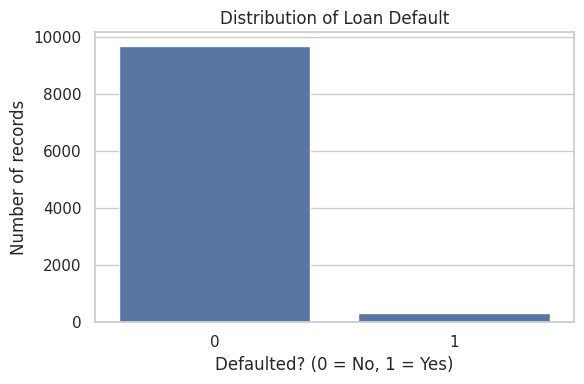

In [4]:
# Check target distribution
target_col = "Defaulted?"

if target_col not in df.columns:
    raise ValueError(
        f"Target column '{target_col}' was not found. "
        f"Available columns: {df.columns.tolist()}"
    )

print("Target counts:")
display(df[target_col].value_counts(dropna=False).rename_axis("Defaulted?").to_frame("Count"))

print("Target percentages:")
display((df[target_col].value_counts(normalize=True, dropna=False) * 100)
        .rename_axis("Defaulted?").to_frame("Percentage").round(2))

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col)
plt.title("Distribution of Loan Default")
plt.xlabel("Defaulted? (0 = No, 1 = Yes)")
plt.ylabel("Number of records")
plt.tight_layout()
plt.show()

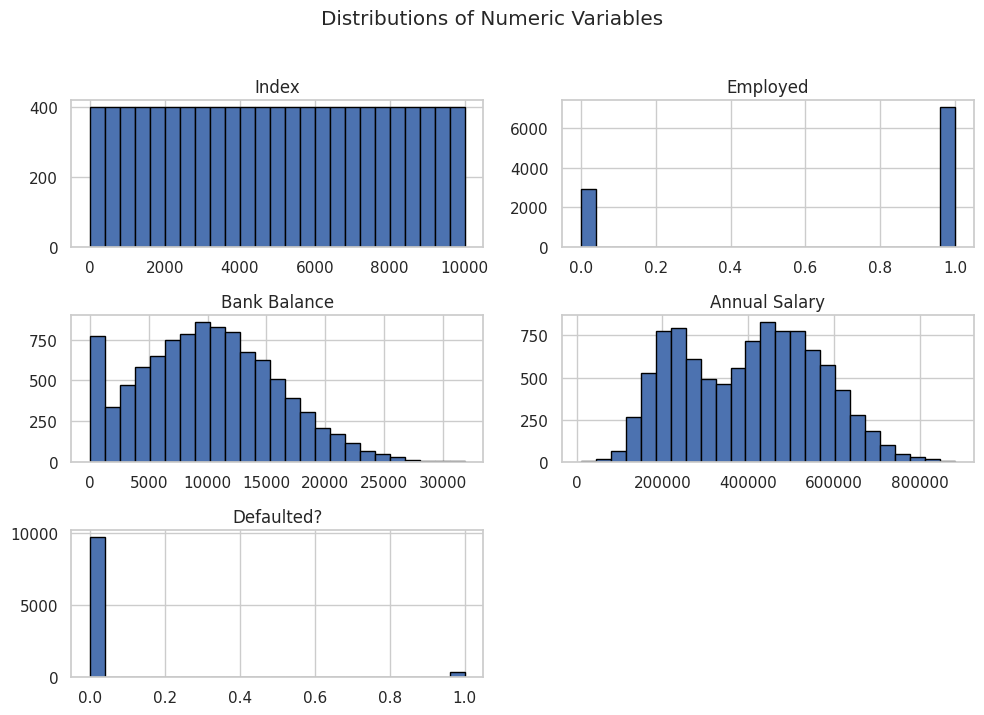

In [5]:

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df[numeric_cols].hist(figsize=(10, 7), bins=25, edgecolor="black")
plt.suptitle("Distributions of Numeric Variables", y=1.02)
plt.tight_layout()
plt.show()

## 4. Data preparation and train-test split

- `Index` is treated as a record identifier and excluded from model training.
- `Defaulted?` is the target to predict.
- Remaining columns are input features.
- We split the data into 80% training and 20% testing records.
- `stratify=y` preserves the target-class proportions in both sets.
- Missing values are handled if present, using median imputation for numeric features and most-frequent imputation for categorical features.

In [6]:

df = df.dropna(subset=[target_col]).copy()


y = df[target_col].astype(int)
if not set(y.unique()).issubset({0, 1}):
    raise ValueError("The target column must contain only 0 and 1.")

drop_cols = [target_col]
if "Index" in df.columns:
    drop_cols.append("Index")

X = df.drop(columns=drop_cols)


X = pd.get_dummies(X, drop_first=False)


X = X.replace([np.inf, -np.inf], np.nan)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Feature columns:", X.columns.tolist())
print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])
print("\nTraining target proportions:")
display(y_train.value_counts(normalize=True).rename("Proportion").to_frame().round(4))
print("\nTesting target proportions:")
display(y_test.value_counts(normalize=True).rename("Proportion").to_frame().round(4))

Feature columns: ['Employed', 'Bank Balance', 'Annual Salary']
Training rows: 8000
Testing rows: 2000

Training target proportions:


,Proportion
Defaulted?,
0,0.9668
1,0.0332



Testing target proportions:


,Proportion
Defaulted?,
0,0.9665
1,0.0335


## 5. Train four classifiers

We use pipelines for Logistic Regression and SVM so that features are scaled before fitting. Class weighting is used for Logistic Regression, Random Forest, and SVM to help account for an imbalanced target. XGBoost uses a positive-class weight calculated from the training data.

These settings are starting points; model tuning and threshold selection could improve performance further.

In [7]:
from sklearn.impute import SimpleImputer

models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=2000,
            random_state=42
        ))
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    "SVM": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", SVC(
            class_weight="balanced",
            probability=True,
            random_state=42
        ))
    ]),
    "XGBoost": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", XGBClassifier(
            n_estimators=200,
            max_depth=3,
            learning_rate=0.05,
            scale_pos_weight=max(1.0, (y_train == 0).sum() / max(1, (y_train == 1).sum())),
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

trained_models = {}
results = []
test_probabilities = {}
test_predictions = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model
    test_predictions[name] = y_pred
    test_probabilities[name] = y_prob

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).set_index("Model")
print("\nModel training complete.")
display(results_df.round(4))

Training Logistic Regression...
Training Random Forest...
Training SVM...
Training XGBoost...

Model training complete.


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Logistic Regression,0.855,0.1730,0.8806,0.2892,0.9487
Random Forest,0.969,0.5758,0.2836,0.3800,0.8772
SVM,0.841,0.1617,0.8955,0.2740,0.9152
XGBoost,0.848,0.1643,0.8657,0.2762,0.9427


## 6. Performance comparison table

Metric meanings:

- **Accuracy:** fraction of all predictions that are correct.
- **Precision:** among customers predicted to default, the fraction who actually defaulted.
- **Recall:** among actual defaulters, the fraction correctly identified.
- **F1-score:** balance between precision and recall.
- **ROC-AUC:** how well the model ranks default cases above non-default cases across thresholds.

Because defaults may be rare, do not select a model using accuracy alone.

,F1 Score,ROC-AUC
Model,,
Random Forest,0.3800,0.8772
Logistic Regression,0.2892,0.9487
XGBoost,0.2762,0.9427
SVM,0.2740,0.9152


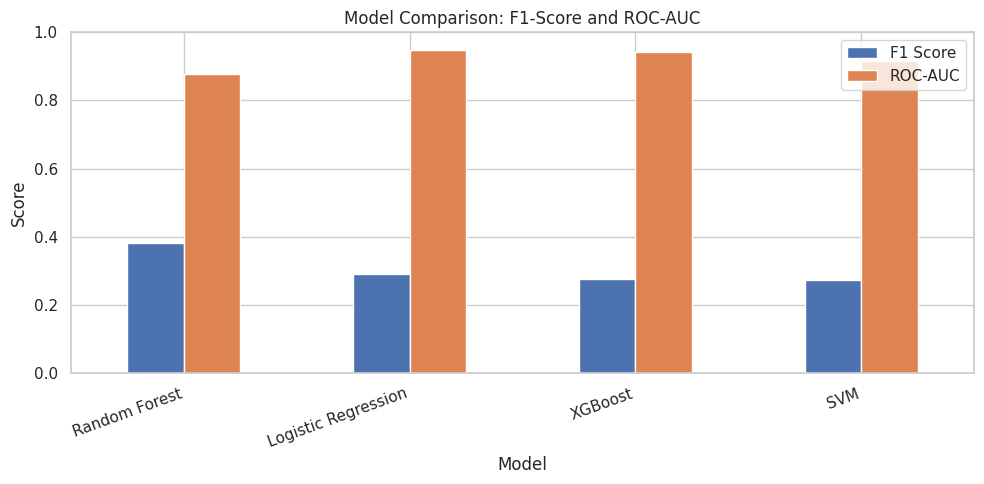

In [8]:

comparison = results_df[["F1 Score", "ROC-AUC"]].sort_values("F1 Score", ascending=False)
display(comparison.round(4))

ax = comparison.plot(kind="bar", figsize=(10, 5))
ax.set_title("Model Comparison: F1-Score and ROC-AUC")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha="right")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

## 7. Select the best model and display its classification report

For this project, we select the model with the highest **F1-score** on the held-out test set. This is a transparent baseline selection rule because it balances precision and recall. For real lending applications, the decision should also consider the cost of missed defaults, false positives, calibration, fairness, and business requirements.

In [9]:
best_name = results_df["F1 Score"].idxmax()
best_model = trained_models[best_name]
best_pred = test_predictions[best_name]
best_prob = test_probabilities[best_name]

print("Best model by test F1-score:", best_name)
print("\nClassification report:")
print(classification_report(
    y_test,
    best_pred,
    target_names=["No Default (0)", "Default (1)"],
    zero_division=0
))

print("Selected model metrics:")
display(results_df.loc[[best_name]].round(4))

Best model by test F1-score: Random Forest

Classification report:
                precision    recall  f1-score   support

No Default (0)       0.98      0.99      0.98      1933
   Default (1)       0.58      0.28      0.38        67

      accuracy                           0.97      2000
     macro avg       0.78      0.64      0.68      2000
  weighted avg       0.96      0.97      0.96      2000

Selected model metrics:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Random Forest,0.969,0.5758,0.2836,0.38,0.8772


## 8. Confusion matrix and ROC curve

The confusion matrix displays correct and incorrect classifications. In particular, the bottom-left cell (actual default, predicted no default) represents defaulters missed by the model.

The ROC curve shows the trade-off between true-positive rate and false-positive rate at different probability thresholds.

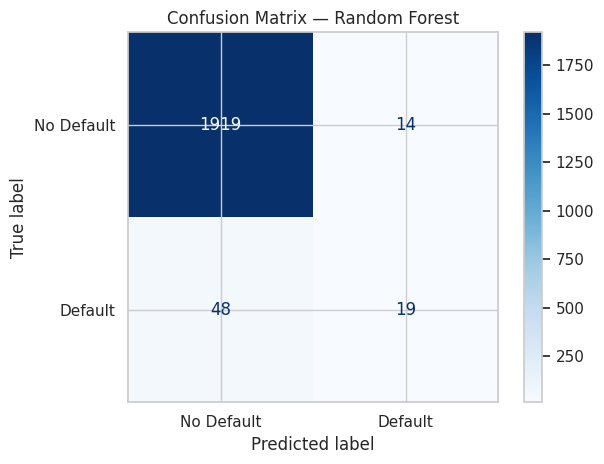

In [10]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    best_pred,
    display_labels=["No Default", "Default"],
    cmap="Blues",
    values_format="d"
)
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.show()

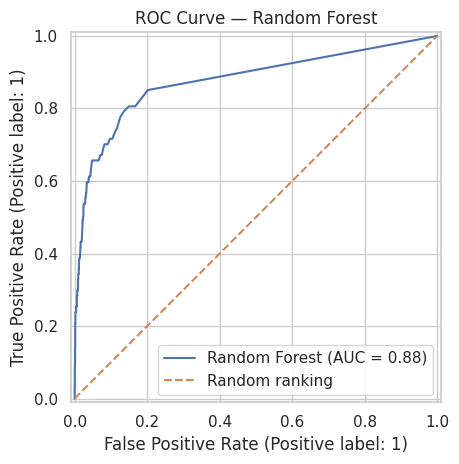

In [11]:
RocCurveDisplay.from_predictions(y_test, best_prob, name=best_name)
plt.plot([0, 1], [0, 1], linestyle="--", label="Random ranking")
plt.title(f"ROC Curve — {best_name}")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature importance and interpretation

Permutation importance measures how much the selected model's F1-score changes when one feature is randomly shuffled. A larger positive decrease suggests that the model relies more on that feature for its predictions.

This shows predictive importance, not causation. Results can be unstable when features are correlated or the dataset is small.

,Feature,Mean Importance,Standard Deviation
1,Bank Balance,0.35783,0.01798
0,Employed,0.07059,0.02256
2,Annual Salary,0.05228,0.05221


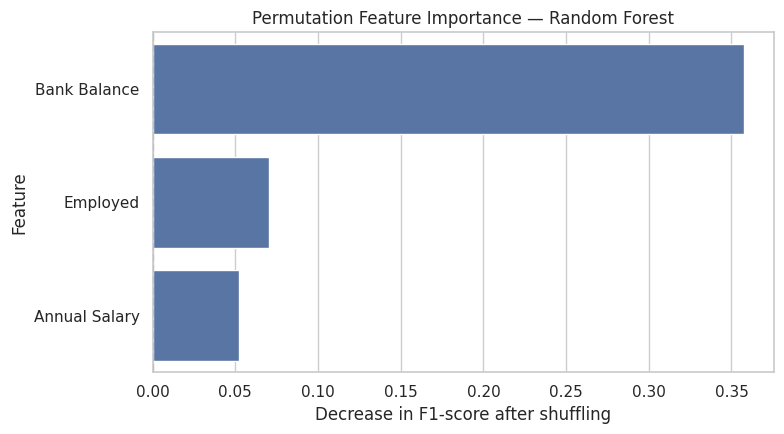

In [12]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Importance": perm.importances_mean,
    "Standard Deviation": perm.importances_std
}).sort_values("Mean Importance", ascending=False)

display(importance_df.round(5))

plt.figure(figsize=(8, 4.5))
sns.barplot(
    data=importance_df,
    x="Mean Importance",
    y="Feature"
)
plt.axvline(0, linestyle="--")
plt.title(f"Permutation Feature Importance — {best_name}")
plt.xlabel("Decrease in F1-score after shuffling")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 10. Conclusion and limitations

### Conclusion

This project prepared the bank loan dataset and trained four classifiers: Logistic Regression, Random Forest, SVM, and XGBoost. The models were compared using accuracy, precision, recall, F1-score, and ROC-AUC. The model with the highest test F1-score was selected for further evaluation using a classification report, confusion matrix, ROC curve, and permutation feature importance.


### Limitations

1. The dataset contains only a small set of features, so it may not capture the full reasons behind loan default.
2. The default class is imbalanced; a high accuracy score can hide poor detection of defaulters.
3. The model was evaluated on one train-test split. Cross-validation and hyperparameter tuning would give a more robust comparison.
4. Permutation importance describes predictive usefulness, not cause and effect.
5. Lending models require careful checks for bias, fairness, privacy, calibration, and compliance before real-world use.
6. The model's predictions are educational estimates and should not be used alone to approve or reject actual loan applications.

### Libraries and tools used

- Python
- Pandas and NumPy
- Matplotlib and Seaborn
- Scikit-learn
- XGBoost
- Google Colab